# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv('Updated Quality of Life Data.csv', low_memory=False)

df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


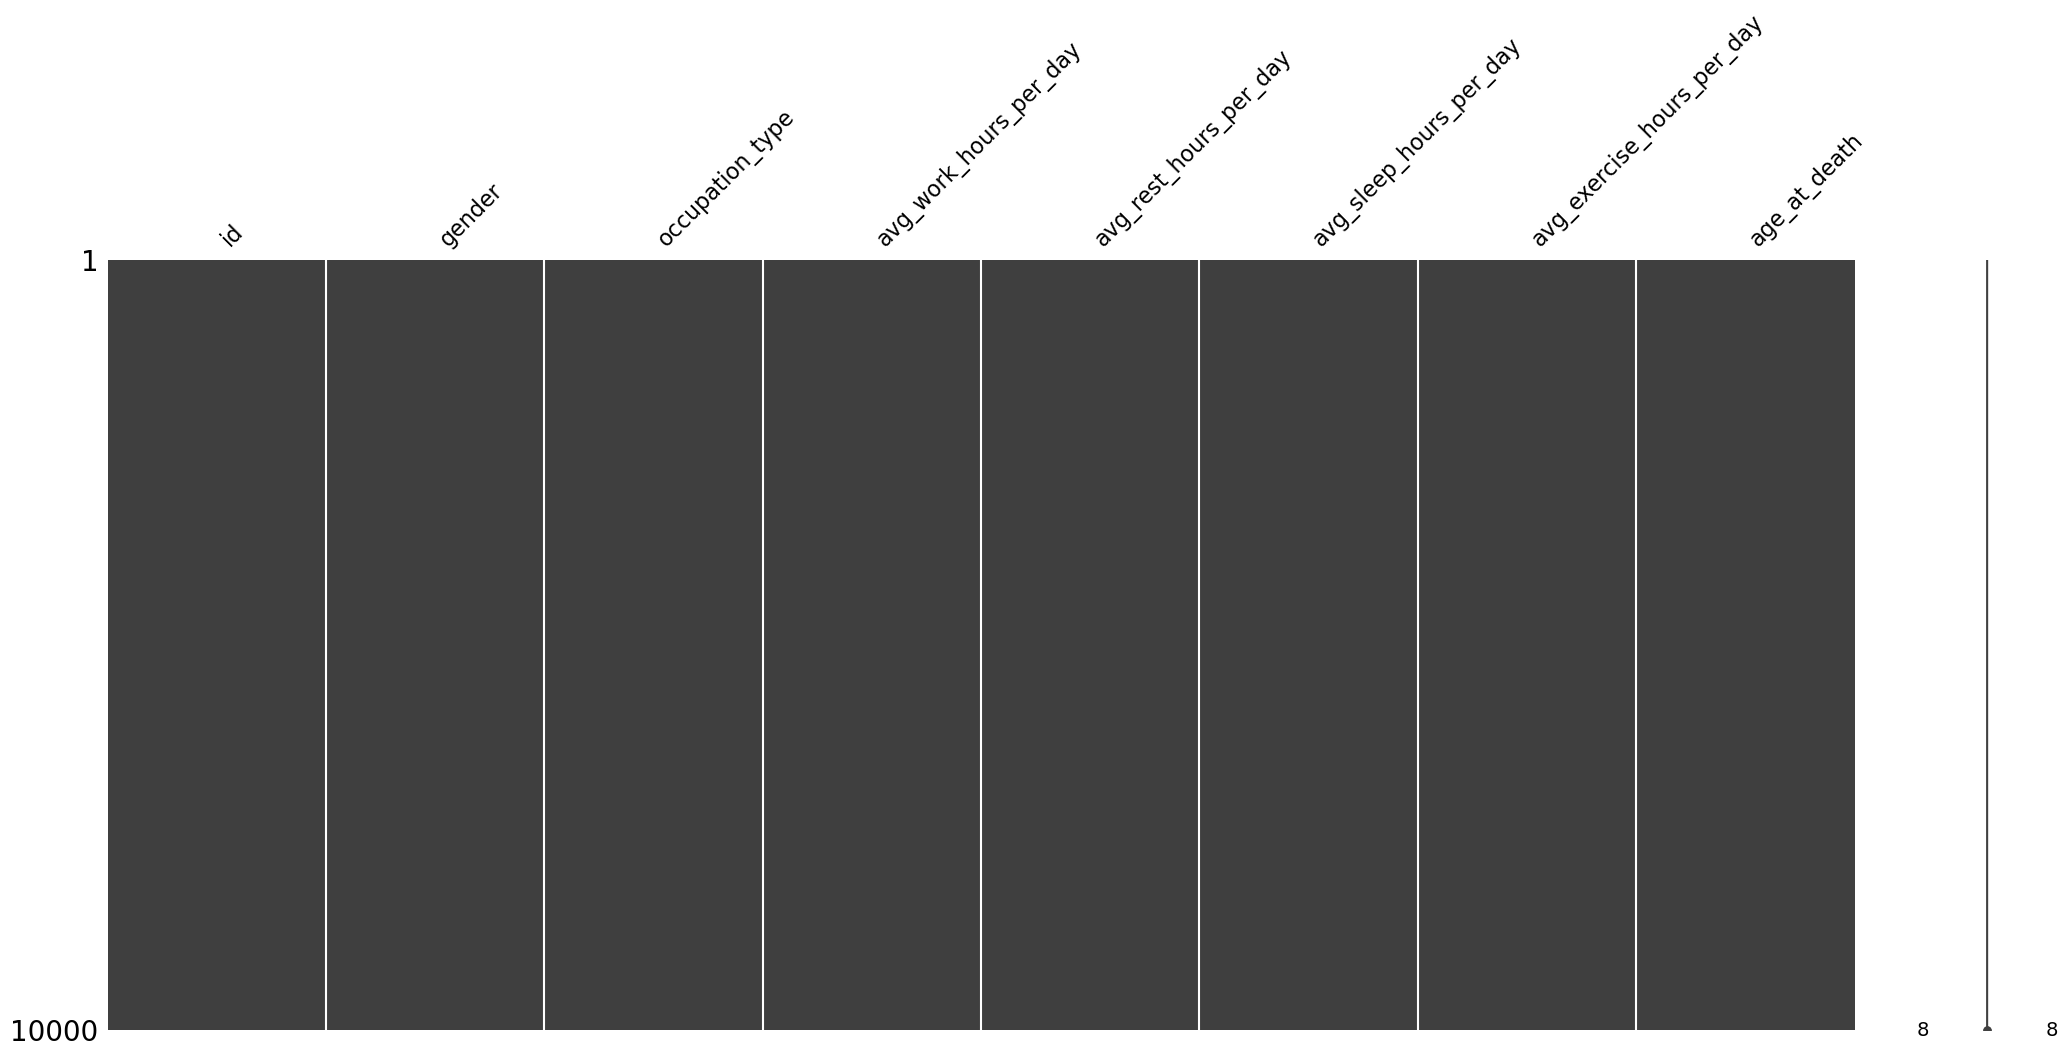

In [2]:
msno.matrix(df)
plt.show()

No missing data, and well described columns. 


What is the Typical age at death. Are there any outliers?

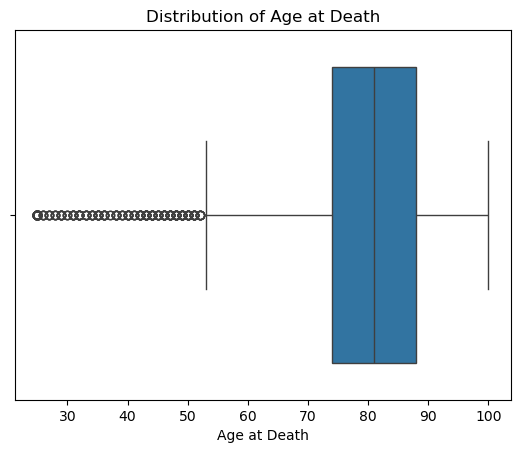

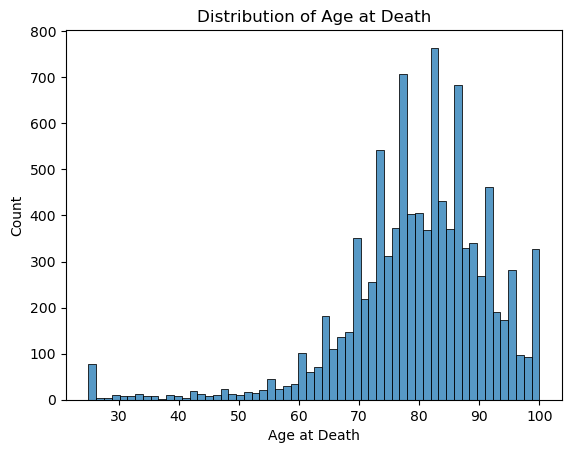

In [3]:
sns.boxplot(x="age_at_death", data=df)
plt.title("Distribution of Age at Death")
plt.xlabel("Age at Death")
plt.show()

#Histogram of price
sns.histplot(x="age_at_death", data=df)
plt.title("Distribution of Age at Death")
plt.xlabel("Age at Death")
plt.show()

There is actually a fairly large numeber in the youngest age group. Lets see what that data set says about their lifestyle before moving to the general age group

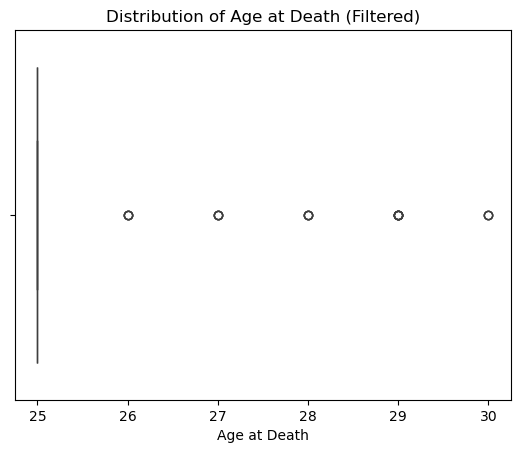

In [4]:
# filter out outliers
df_filtered_outliers = df[df['age_at_death'] <= 30]
sns.boxplot(x="age_at_death", data=df_filtered_outliers)
plt.title("Distribution of Age at Death (Filtered)")
plt.xlabel("Age at Death")
plt.show()

In [5]:
# analyse the df_filtered_outliers
print(df_filtered_outliers.describe())

                 id  avg_work_hours_per_day  avg_rest_hours_per_day  \
count     96.000000               96.000000               96.000000   
mean   15061.718750               21.610313                1.159375   
std     2693.260144                3.319042                0.857883   
min    10197.000000                0.370000                0.000000   
25%    12978.000000               21.382500                0.547500   
50%    15145.000000               22.215000                0.940000   
75%    17272.250000               23.090000                1.637500   
max    19585.000000               23.970000                3.700000   

       avg_sleep_hours_per_day  avg_exercise_hours_per_day  age_at_death  
count                96.000000                   96.000000     96.000000  
mean                  1.230417                    0.008750     25.697917  
std                   2.963382                    0.064208      1.437247  
min                   0.000000                    0.000000  

Although there is missing data "visually", there is extremely innaccurate data for these outliers. ALmost all of which are listed as working almost 24 hours a day and sleeping less than 3 hours. Some of these may be true, but not all 96 of them.

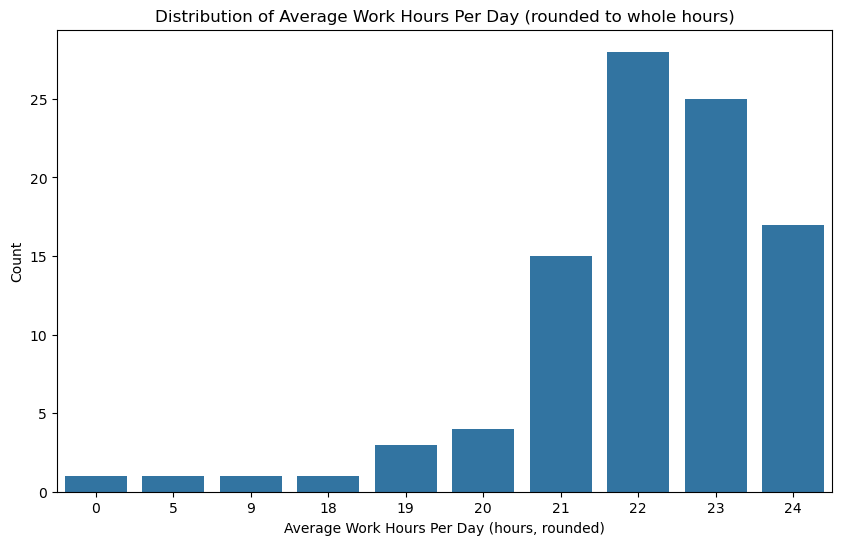

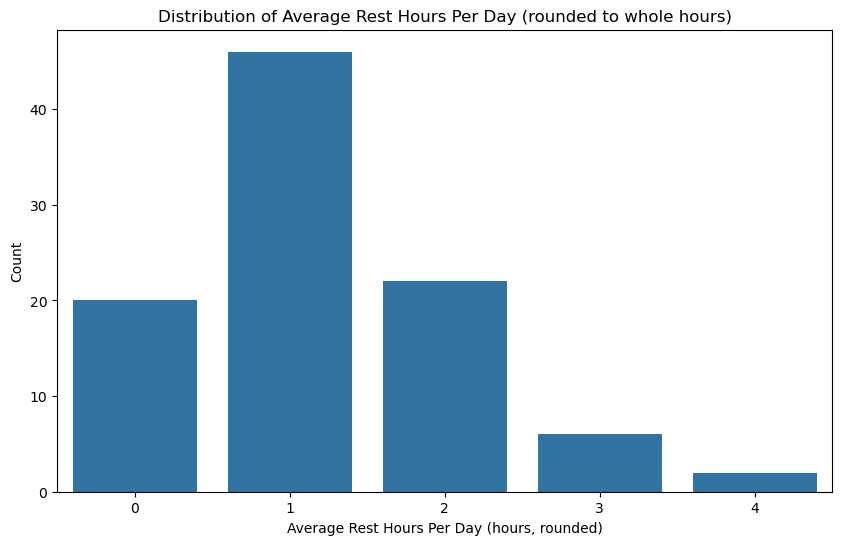

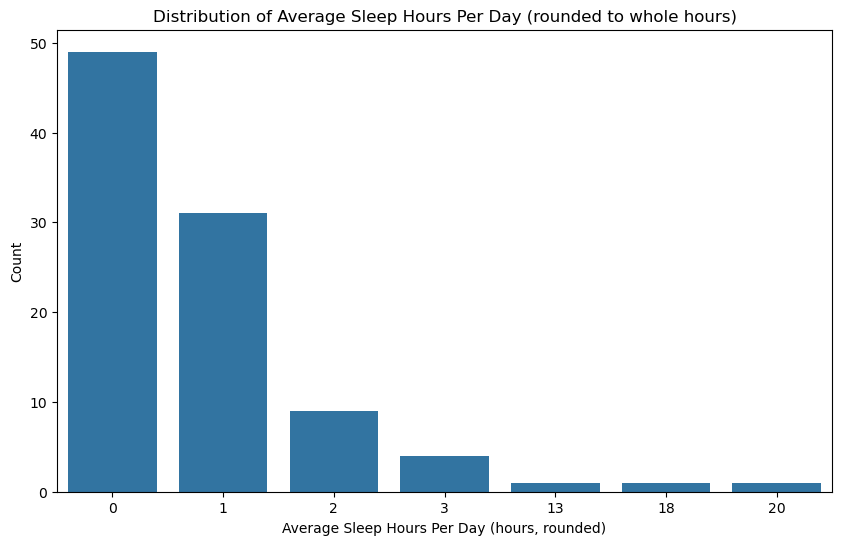

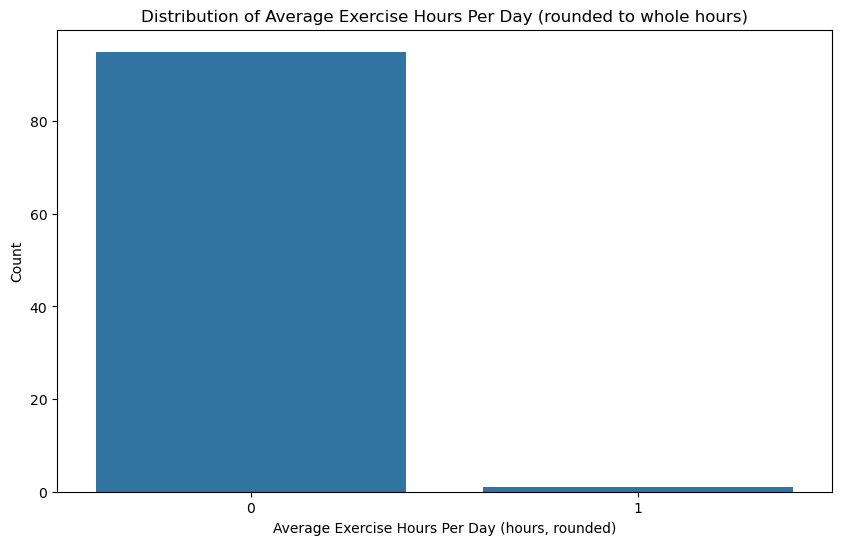

In [8]:
# Bar plots for key categorical variables
categorical_features = ['avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']

feature_titles = {
    'avg_work_hours_per_day': 'Average Work Hours Per Day',
    'avg_rest_hours_per_day': 'Average Rest Hours Per Day',
    'avg_sleep_hours_per_day': 'Average Sleep Hours Per Day',
    'avg_exercise_hours_per_day': 'Average Exercise Hours Per Day'
}

    
for feature in categorical_features:
    # round to whole numbers (hours) without modifying the original dataframe
    rounded = df_filtered_outliers[feature].round().astype(int)
    order = sorted(rounded.unique())
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=rounded, order=order)
    
    plt.title(f"Distribution of {feature_titles[feature]} (rounded to whole hours)")
    plt.xlabel(f"{feature_titles[feature]} (hours, rounded)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

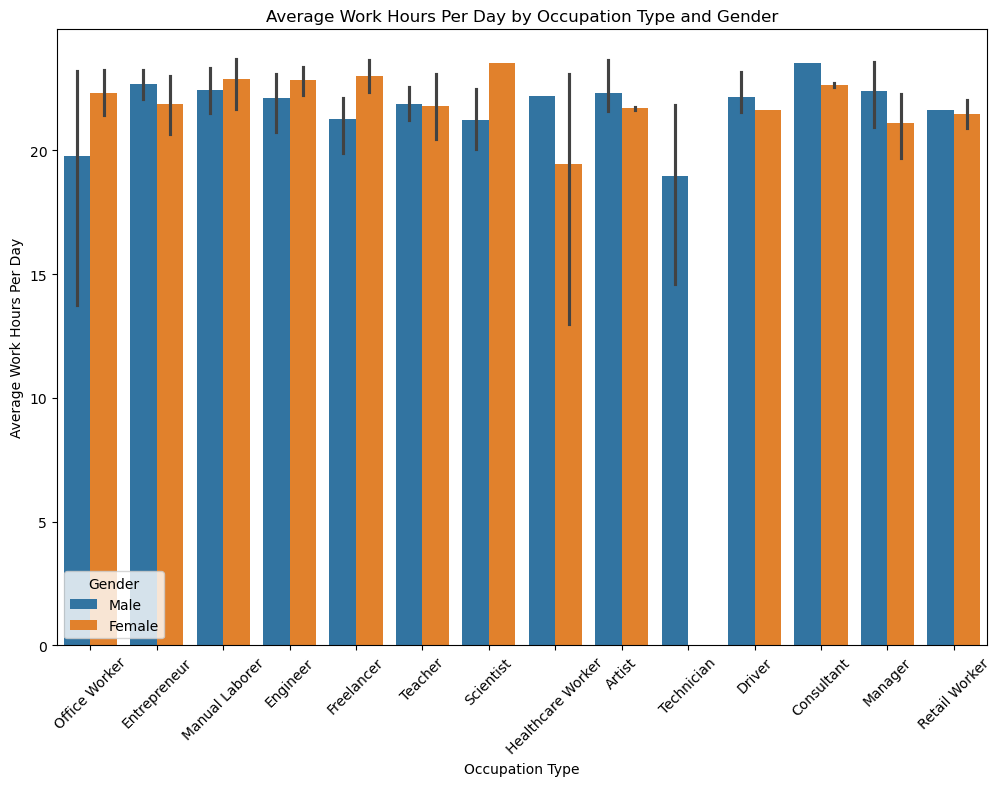

In [9]:
# Compare ocupation_type and gender with avg_work_hours_per_day
plt.figure(figsize=(12, 8))
sns.barplot(x='occupation_type', y='avg_work_hours_per_day', hue='gender', data=df_filtered_outliers)
plt.title("Average Work Hours Per Day by Occupation Type and Gender")
plt.xlabel("Occupation Type")
plt.ylabel("Average Work Hours Per Day")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()

With these outliers have a fairly even spread of gender/occupation/and an extremely high number of work hours per day, all of which died before the age of 30 tells me there is something wrong with this data. How long were these individuals tracked for this research? If they were in fact living everyday with absolutely no sleep, then I can understand the early mortality, most likely a workplace accident during sleep depravation. But I'm just ruling these out completely because it is a fairly even spread amongst all occupations and genders (except technician having no females) as to not skew any other data.

Now we'll look at the general age groups.

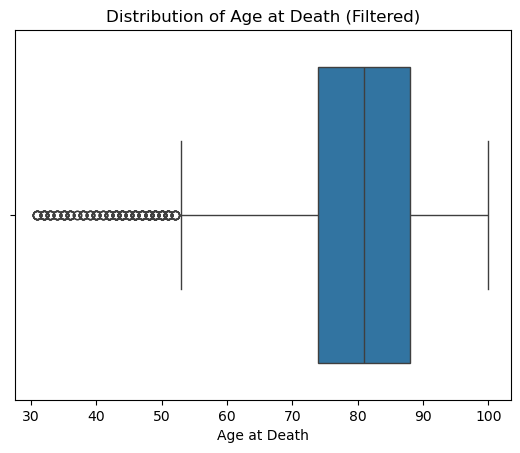

In [10]:
# filter out outliers
df_filtered = df[df['age_at_death'] >= 31]
sns.boxplot(x="age_at_death", data=df_filtered)
plt.title("Distribution of Age at Death (Filtered)")
plt.xlabel("Age at Death")
plt.show()

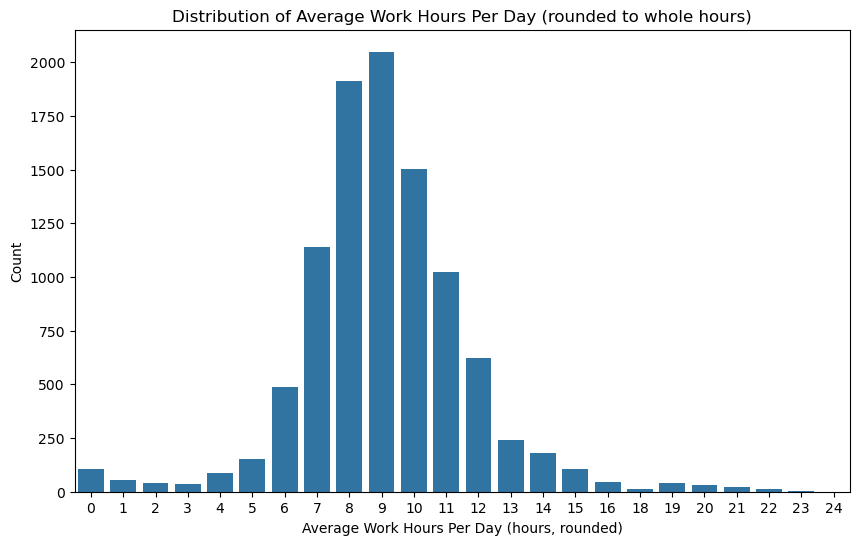

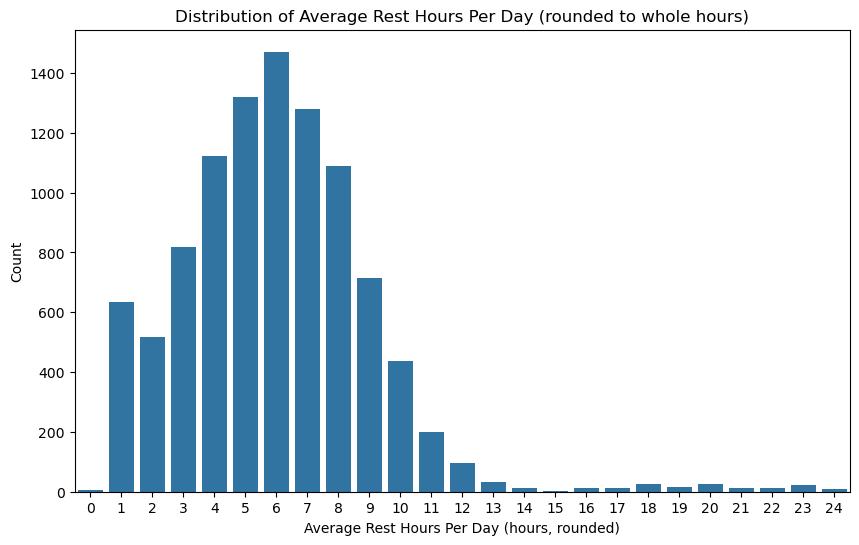

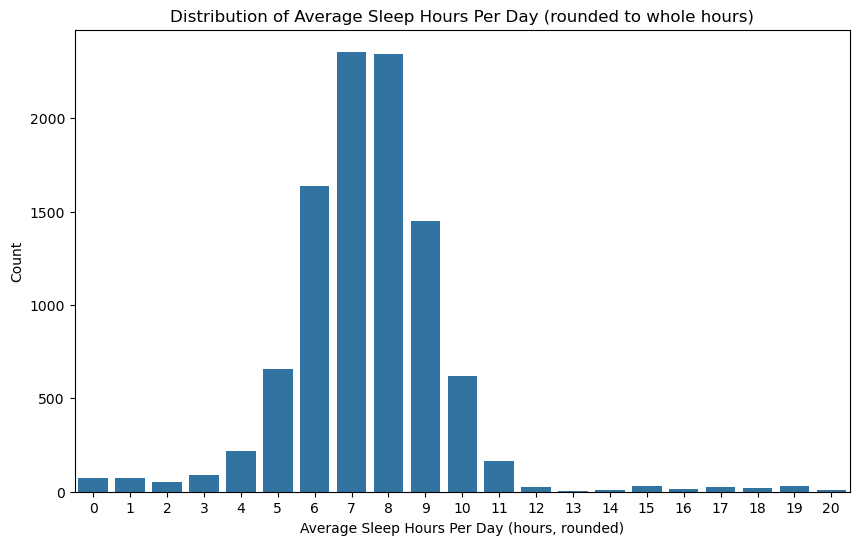

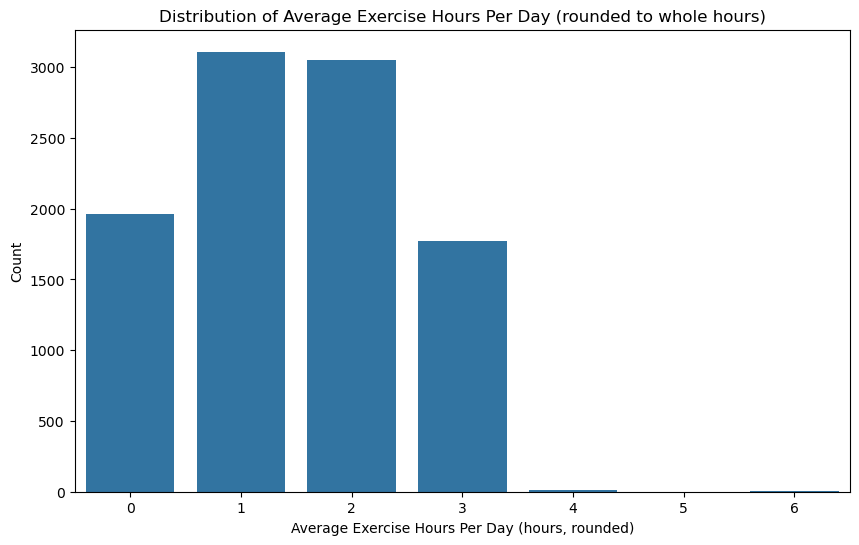

In [11]:
# Bar plots for key categorical variables
categorical_features = ['avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']

feature_titles = {
    'avg_work_hours_per_day': 'Average Work Hours Per Day',
    'avg_rest_hours_per_day': 'Average Rest Hours Per Day',
    'avg_sleep_hours_per_day': 'Average Sleep Hours Per Day',
    'avg_exercise_hours_per_day': 'Average Exercise Hours Per Day'
}

    
for feature in categorical_features:
    # round to whole numbers (hours) without modifying the original dataframe
    rounded = df_filtered[feature].round().astype(int)
    order = sorted(rounded.unique())
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=rounded, order=order)
    
    plt.title(f"Distribution of {feature_titles[feature]} (rounded to whole hours)")
    plt.xlabel(f"{feature_titles[feature]} (hours, rounded)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

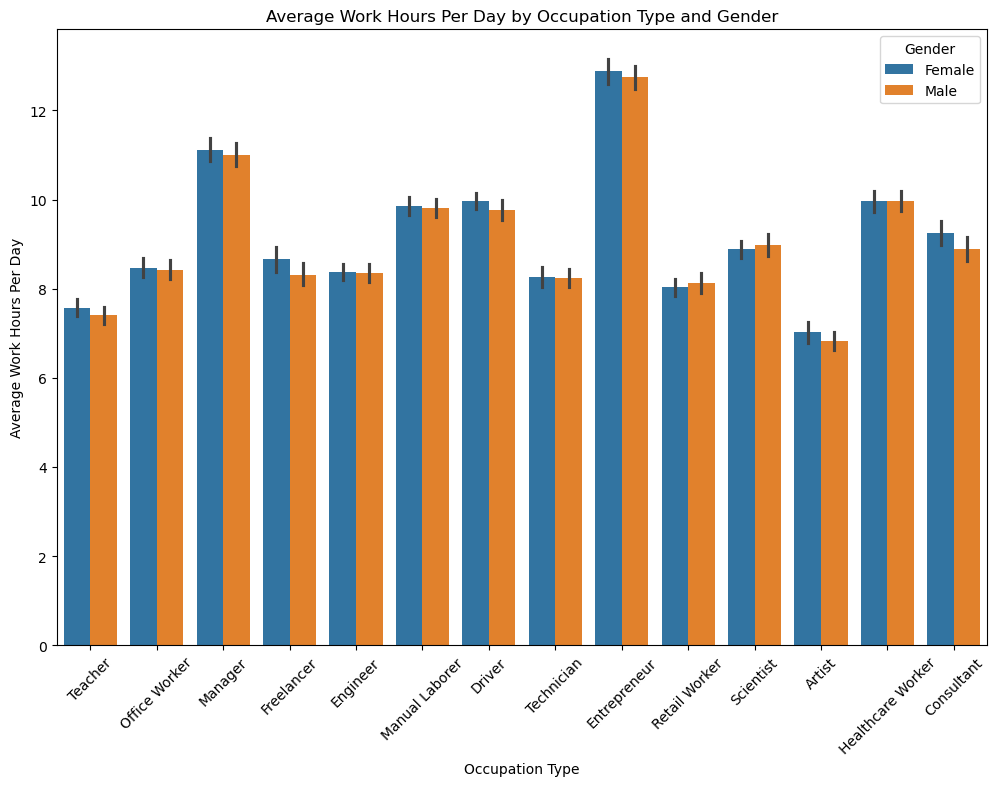

In [12]:
# distribute ocupation_type and gender with avg_work_hours_per_day
plt.figure(figsize=(12, 8))
sns.barplot(x='occupation_type', y='avg_work_hours_per_day', hue='gender', data=df_filtered)
plt.title("Average Work Hours Per Day by Occupation Type and Gender")
plt.xlabel("Occupation Type")
plt.ylabel("Average Work Hours Per Day")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()

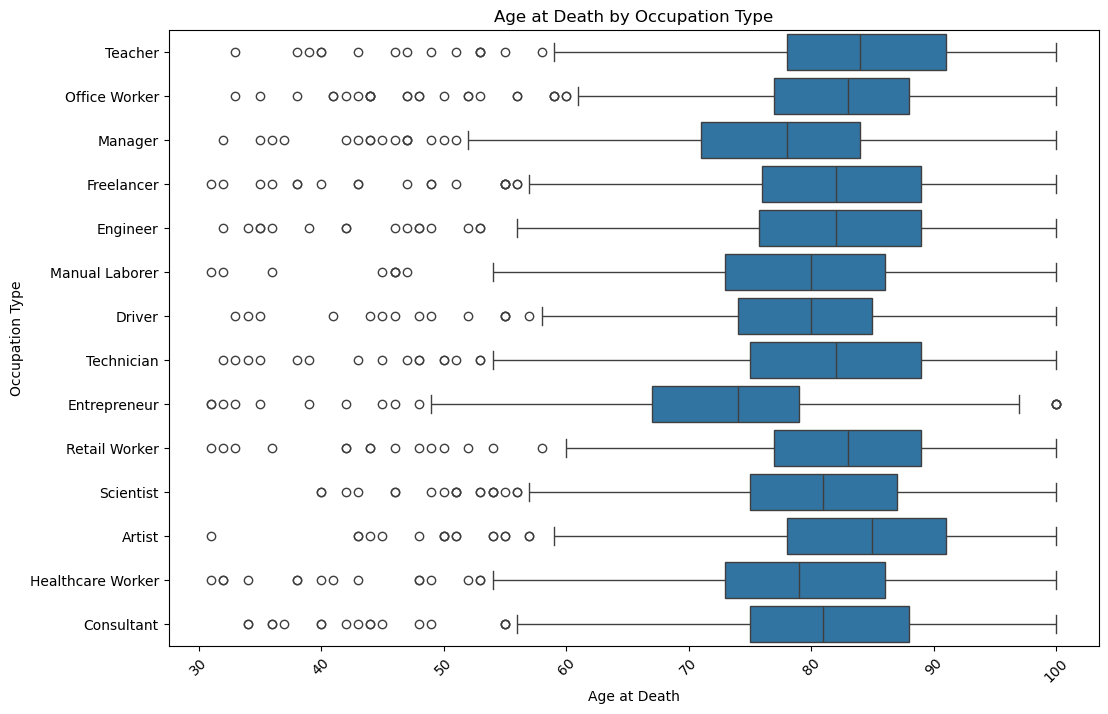

In [15]:
#boxplot of age at death by occupation type
plt.figure(figsize=(12, 8))
sns.boxplot(x='age_at_death', y='occupation_type', data=df_filtered)    
plt.title("Age at Death by Occupation Type")
plt.xlabel("Age at Death")
plt.ylabel("Occupation Type")
plt.xticks(rotation=45)
plt.show()


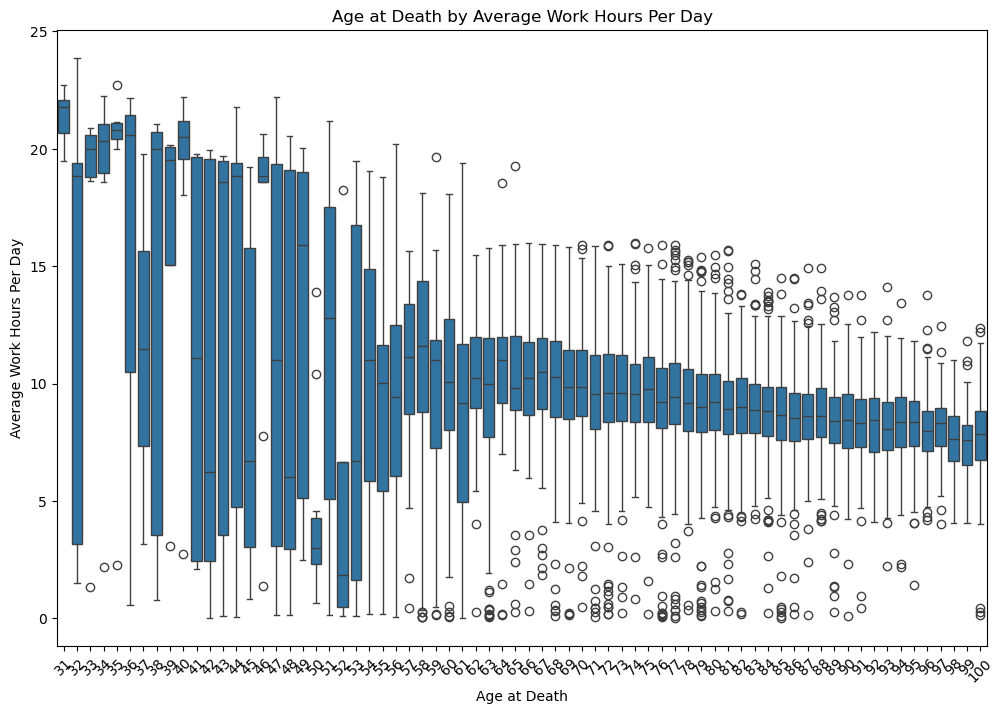

In [21]:
# boxplot of age at death by ave_work_hours_per_day
plt.figure(figsize=(12, 8))
sns.boxplot(x='age_at_death', y='avg_work_hours_per_day', data=df_filtered)
plt.title("Age at Death by Average Work Hours Per Day")
plt.xlabel("Age at Death")
plt.ylabel("Average Work Hours Per Day")
plt.xticks(rotation=45)
plt.show()

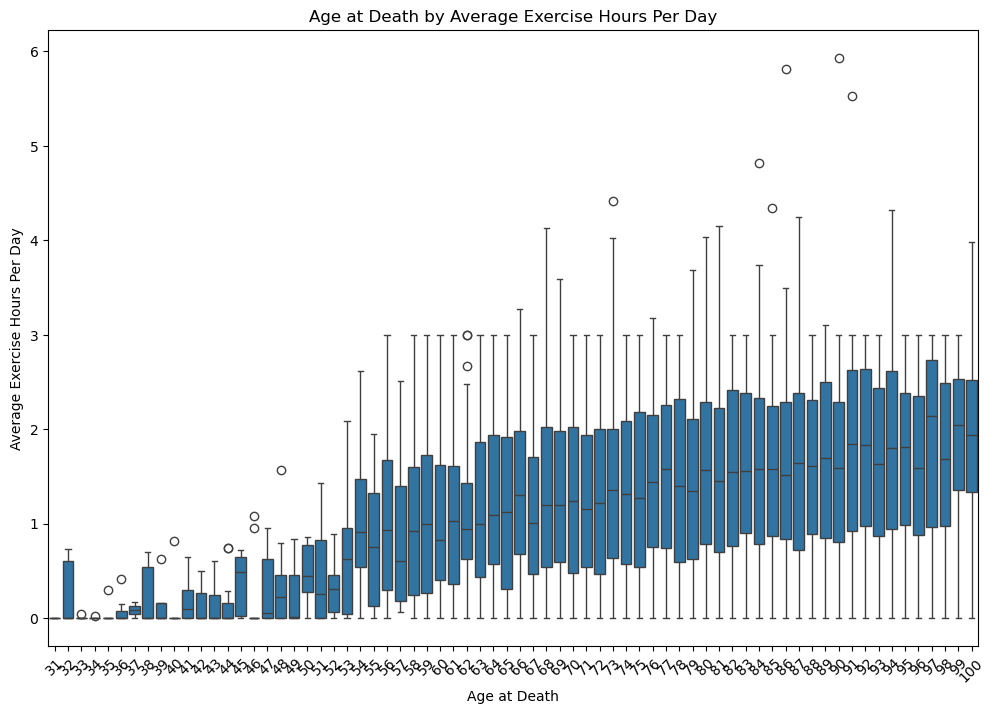

In [16]:
# boxplot of age at death by ave_hours_exercise_per_day
plt.figure(figsize=(12, 8))
sns.boxplot(x='age_at_death', y='avg_exercise_hours_per_day', data=df_filtered)
plt.title("Age at Death by Average Exercise Hours Per Day")
plt.xlabel("Age at Death")
plt.ylabel("Average Exercise Hours Per Day")
plt.xticks(rotation=45)
plt.show()

There is a massive correlation with longevity and exercising for at least 30 minutes per day.

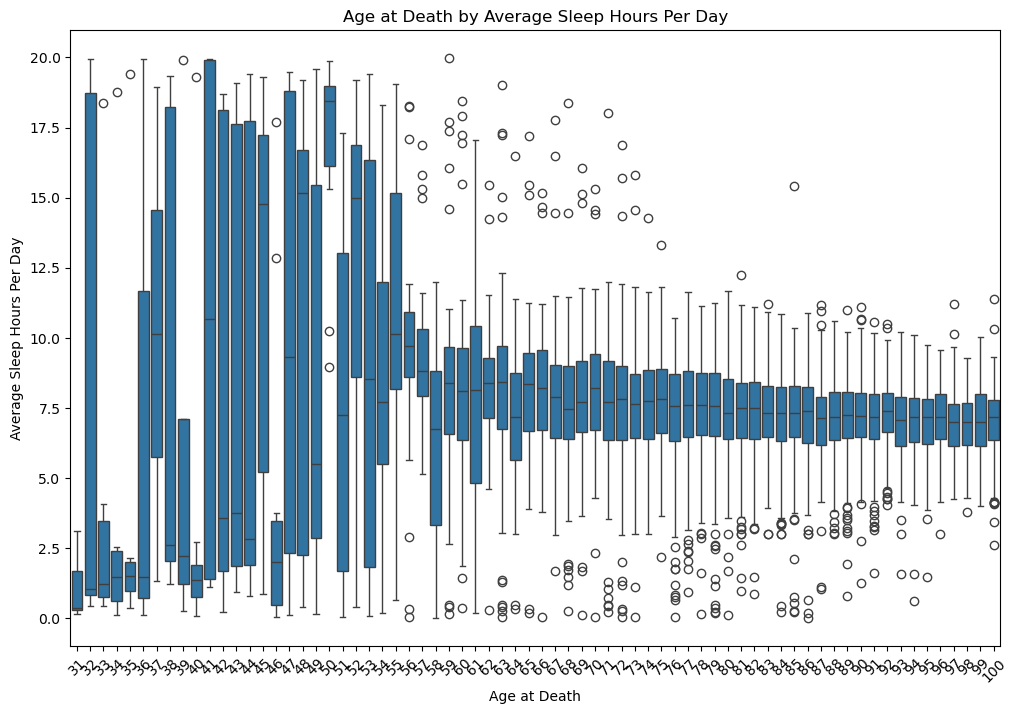

In [17]:
#boxplot of age at death by ave_hours_sleep_per_day
plt.figure(figsize=(12, 8))
sns.boxplot(x='age_at_death', y='avg_sleep_hours_per_day', data=df_filtered)
plt.title("Age at Death by Average Sleep Hours Per Day")
plt.xlabel("Age at Death")
plt.ylabel("Average Sleep Hours Per Day")
plt.xticks(rotation=45)
plt.show()  

Clearly a regimented sleep schedule is correlated with longevity.

Now I want to look at the occupation with the lowest average age at death, and the occupation with the highest average age at death. That would be:

Lowest: Entrepreneur
Highest: Teacher

In [18]:
# analyze the key data features of the Teacher and Entrpreneur occupation types
teacher_data = df_filtered[df_filtered['occupation_type'] == 'Teacher']
entrepreneur_data = df_filtered[df_filtered['occupation_type'] == 'Entrepreneur']   # Calculate mean values for key features
teacher_means = teacher_data[['avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']].mean()
entrepreneur_means = entrepreneur_data[['avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']].mean()    
# Create a DataFrame to compare the means
comparison_df = pd.DataFrame({'Teacher': teacher_means, 'Entrepreneur': entrepreneur_means})
print(comparison_df)

                             Teacher  Entrepreneur
avg_work_hours_per_day      7.485357     12.814677
avg_rest_hours_per_day      7.763386      2.740147
avg_sleep_hours_per_day     7.290106      6.980909
avg_exercise_hours_per_day  1.461362      1.464809


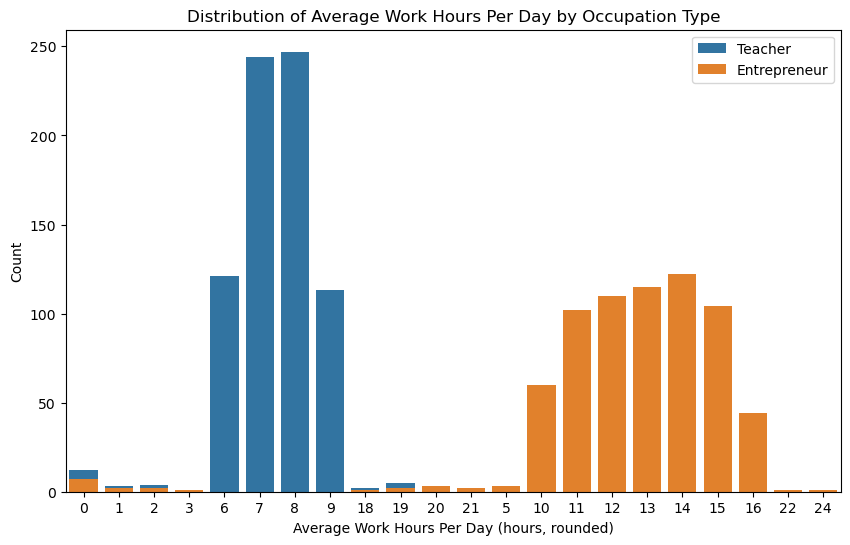

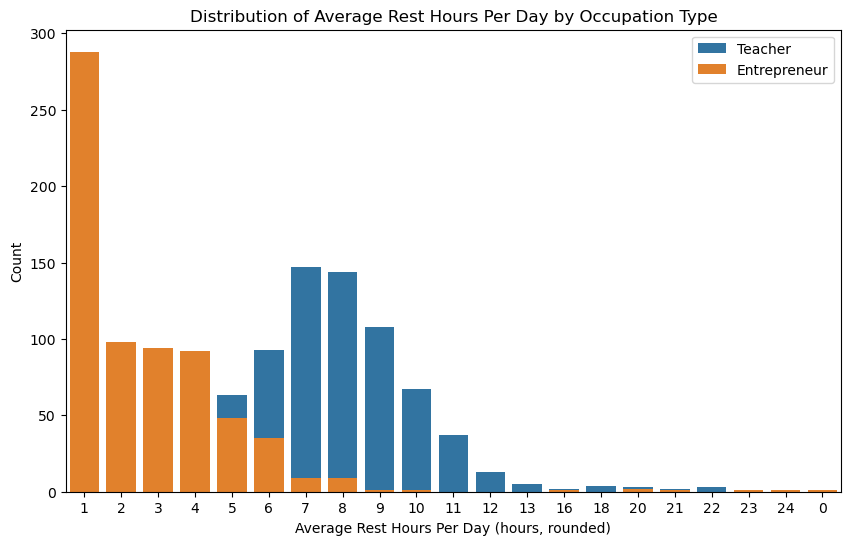

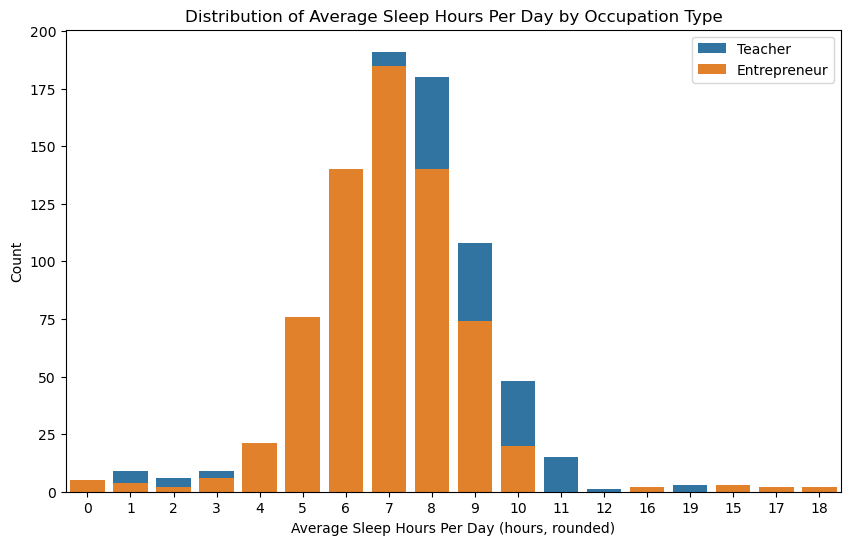

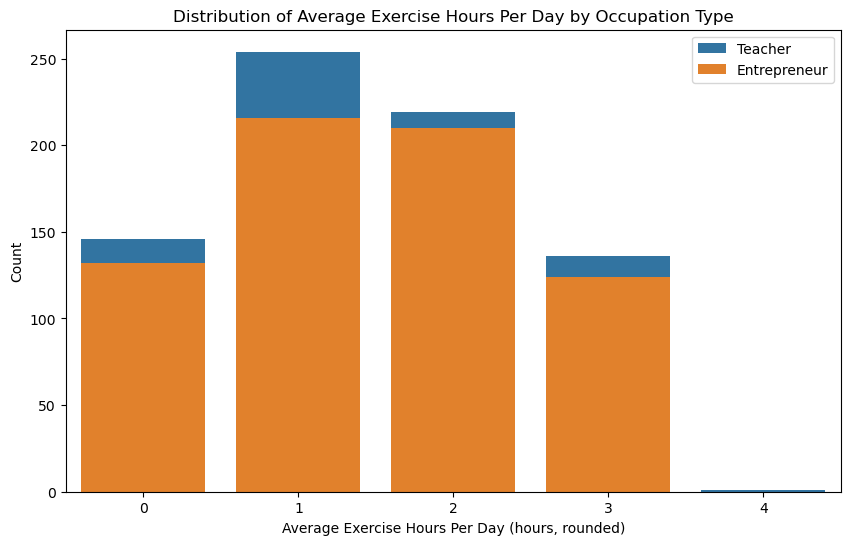

In [20]:
# create a disctribution plot for the average work, rest sleep and exercise hours per day for the Teacher and Entrpreneur occupation types
categorical_features = ['avg_work_hours_per_day', 'avg_rest_hours_per_day', 'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day']

feature_titles = {
    'avg_work_hours_per_day': 'Average Work Hours Per Day',
    'avg_rest_hours_per_day': 'Average Rest Hours Per Day',
    'avg_sleep_hours_per_day': 'Average Sleep Hours Per Day',
    'avg_exercise_hours_per_day': 'Average Exercise Hours Per Day'
}

for feature in categorical_features:
    # round to whole numbers (hours) without modifying the original dataframe
    rounded_teacher = teacher_data[feature].round().astype(int)
    rounded_entrepreneur = entrepreneur_data[feature].round().astype(int)
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=rounded_teacher, label='Teacher')
    sns.countplot(x=rounded_entrepreneur, label='Entrepreneur')
    
    plt.title(f"Distribution of {feature_titles[feature]} by Occupation Type")
    plt.xlabel(f"{feature_titles[feature]} (hours, rounded)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend()
    plt.show()
    

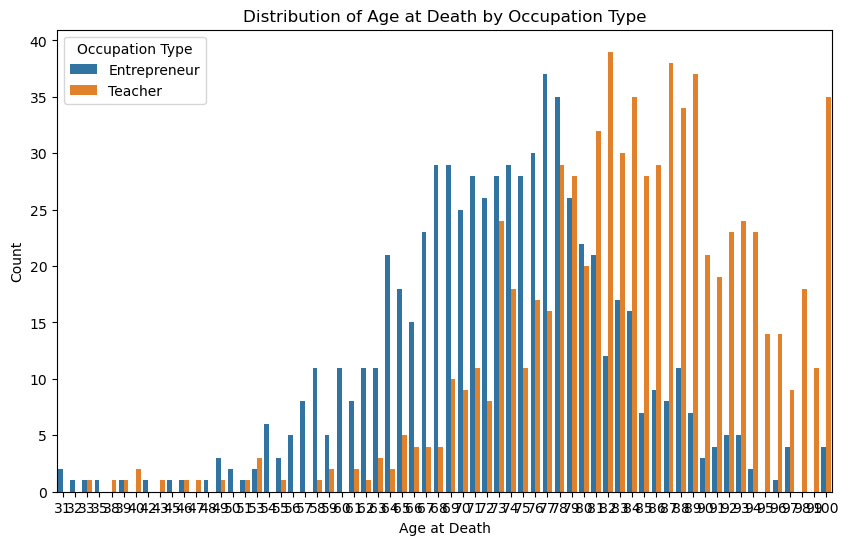

In [23]:
# combine the dataframes for the Teacher and Entrpreneur occupation types
combined_data = pd.concat([teacher_data, entrepreneur_data], axis=0)

# distribution plot for average age at deeath for combined data
plt.figure(figsize=(10, 6))
sns.countplot(x='age_at_death', hue='occupation_type', data=combined_data)
plt.title("Distribution of Age at Death by Occupation Type")
plt.xlabel("Age at Death")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Occupation Type")
plt.show()

So there is a clear correlation between getting adequate rest, exercise and rest time while also not working a tremendous amount. But the largest spread found in the data is between the two occupations of Entrepreneur and Teacher, and that spread was in average work hours. Looking further into those occupations shows us that even with adequate excersize, loss of even a little bit of sleep (entrepreneur sleep data is only marginally lower than recommended) can have a negative impact on Longevity. But, most of all, average work-hours-per-day is the biggest differenctiator between the two occupation. Entrepreneurs working on-average between 10-16 hours per day and teachers working on-average 6-9 hours per day. With those work hours, and a feature that should have been included in this dataset, is average stress levels. Speaking completely subjectively, I belive the elevated stress levels COMBINED with the longer overall workday creates a magnified effect on health and longevity, despite exercise and sleep. So I would say, you occupation choice has a huge factor in longevity. 

Lets actually add another visualization of Entrepreneur age of death correlated with hours of exercise.

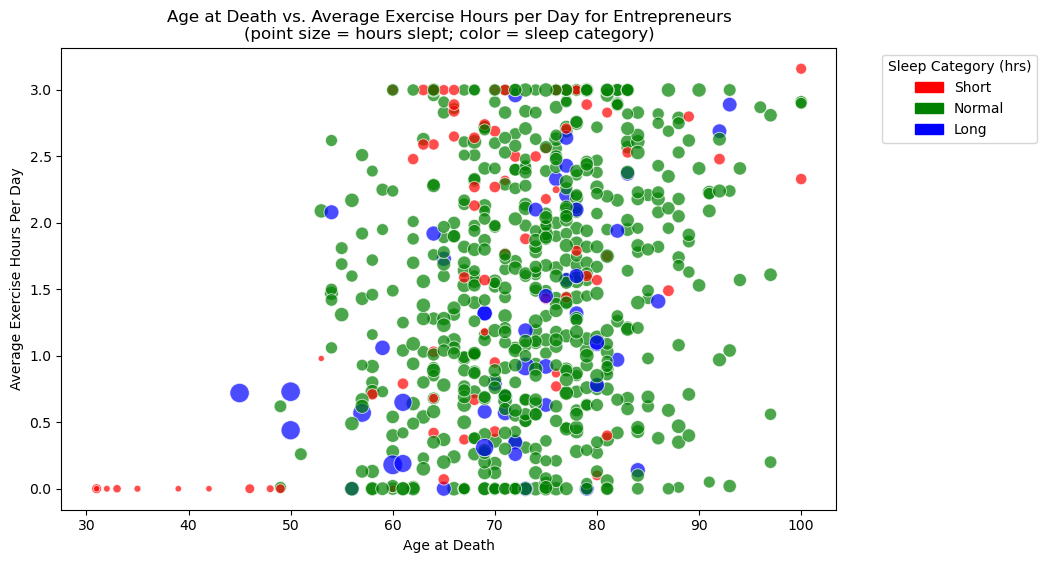

In [30]:
from matplotlib.patches import Patch

# distribution entrepreneur_data with age at death and hours of exercise per day
plt.figure(figsize=(10, 6))

# categorize sleep hours so smaller (less sleep) points can be colored differently
sleep_cat = pd.cut(
    entrepreneur_data['avg_sleep_hours_per_day'],
    bins=[0, 5, 9, 24],
    labels=['short', 'normal', 'long']
)
palette = {'short': 'red', 'normal': 'green', 'long': 'blue'}

# plot scatter but suppress seaborn's automatic legend (which includes size entries)
ax = sns.scatterplot(
    x='age_at_death',
    y='avg_exercise_hours_per_day',
    size='avg_sleep_hours_per_day',
    sizes=(20, 200),
    hue=sleep_cat,
    palette=palette,
    data=entrepreneur_data,
    alpha=0.7,
    legend=False
)

plt.title("Age at Death vs. Average Exercise Hours per Day for Entrepreneurs\n(point size = hours slept; color = sleep category)")
plt.xlabel("Age at Death")
plt.ylabel("Average Exercise Hours Per Day")

# create a compact legend for sleep categories only
handles = [Patch(color=palette[k], label=k.capitalize()) for k in palette]
plt.legend(handles=handles, title='Sleep Category (hrs)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Finally, we can see that with the occupation that has the Highest Mortality rate, exercise with adequate sleep also correlates with higher longevity. So it become critically more important to exercise and sleep appropriately when working High-stress jobs.